In [1]:
import numpy as np
# import density_field_library as DFL
import matplotlib.pyplot as plt
from math import pi

import Pk_library as PKL
import config as config
import my_remote_spectra as rs
# import remote_spectra as rs
import kszpsz_config as kszpsz_config

import importlib
# from scipy.interpolate import RegularGridInterpolator
# from scipy.interpolate import interp1d
import healpy as hp
import my_tools
from IPython.core.interactiveshell import InteractiveShell
InteractiveShell.ast_node_interactivity = "all"

In [2]:
Omega_b = config.Omega_b
Omega_c = config.Omega_c
w = config.w
wa = config.wa
Omega_K = config.Omega_K
h = config.h
As= config.As
ns = config.ns
mirror = True

In [3]:
grid              = 64  #grid size
BoxSize           = 30000 #Mpc
seed              = 1    #value of the initial random seed # varing seed
Rayleigh_sampling = 0     #whether sampling the Rayleigh distribution for modes amplitudes
threads           = 1      #number of openmp threads
verbose           = True   #whether to print some information

d = BoxSize/grid #Mpc
SampleRate = 1/d #1/Mpc
Max_k = 1/2*2*pi*SampleRate #h/Mpc, 2 from Nyquist theorem
Min_k = 2*pi/BoxSize #1/Mpc
print(f'd={d} Mpc') #Mpc/1
print(f'k_min = {Min_k} 1/Mpc') #1/Mpc
print(f'k_max = {Max_k} 1/Mpc') #1/Mpc

# k calculated by pylian3
kF,kN,kmax_par,kmax_per,kmax = PKL.frequencies(BoxSize, grid)
print(kF) #1/Mpc
print(kN) #1/Mpc

d=468.75 Mpc
k_min = 0.00020943951023931953 1/Mpc
k_max = 0.006702064327658226 1/Mpc
0.00020943951023931953
0.006702064327658225


In [4]:
# 3-d real space axes
d = BoxSize/grid #Mpc
x = np.arange(-BoxSize/2, BoxSize/2, d) #Mpc
y = np.arange(-BoxSize/2, BoxSize/2, d) #Mpc
z = np.arange(-BoxSize/2, BoxSize/2, d) #Mpc

if mirror:
    x = np.arange(-BoxSize/2, BoxSize/2, d) #Mpc
    y = np.arange(-BoxSize/2, BoxSize/2, d) #Mpc
    z = np.arange(-BoxSize/2, BoxSize*3/2, d) #Mpc 
    z_left = np.arange(-BoxSize/2, BoxSize/2, d) #Mpc
    _, _, zz_left = np.meshgrid(x, y, z_left, indexing='ij')
# 3-d meshgrid coordinate 
# xx, yy = np.meshgrid(x, y)
xx, yy, zz = np.meshgrid(x, y, z, indexing='ij')
rr = np.sqrt(xx**2 + yy**2 + zz**2)
print(xx.shape)

(64, 64, 128)


In [5]:
factor = 2*pi
k_x = factor*np.fft.fftfreq(grid, d)
k_y = factor*np.fft.fftfreq(grid, d)
k_z = factor*np.fft.fftfreq(grid, d)

if mirror:
    k_x = factor*np.fft.fftfreq(grid, d)
    k_y = factor*np.fft.fftfreq(grid, d)
    k_z = factor*np.fft.fftfreq(2*grid, d)
    
kk_x, kk_y, kk_z = np.meshgrid(k_x, k_y, k_z, indexing='ij')
kk  = np.sqrt(kk_x**2 + kk_y**2 + kk_z**2)
    
# kk_x_s, kk_y_s, kk_z_s = np.fft.fftshift(kk_x), np.fft.fftshift(kk_y), np.fft.fftshift(kk_z)
# kk_s  = np.sqrt(kk_x_s**2 + kk_y_s**2 + kk_z_s**2)
print(kk.shape)

(64, 64, 128)


# Import bubble collision parameters

In [42]:
# Now let's add the inhomogeneous potential psi_i_x where i for inhomogeneous
import param
importlib.reload(param)
A = param.A
B = param.B
direction = param.direction
z_c = param.z_c

A = 1
B = 0
direction = 'z'
z_c = 0
x_c = rs.chifromz(z_c) #Mpc
r_H = param.r_H #Mpc

Z_e = 1
a_e = 1/(1+Z_e)

if 1:
    print(A)
    print(B)
    print(z_c)
    print(x_c)
    print(f'r_H = {r_H} Mpc') #Mpc

<module 'param' from '/home/hongbo/tools/ReCCO/code/param.py'>

1
0
0
0.0
r_H = 4411.764705882353 Mpc


Text(0.5, 0, '$x\\ [Mpc]$')

Text(0, 0.5, '$\\psi$')

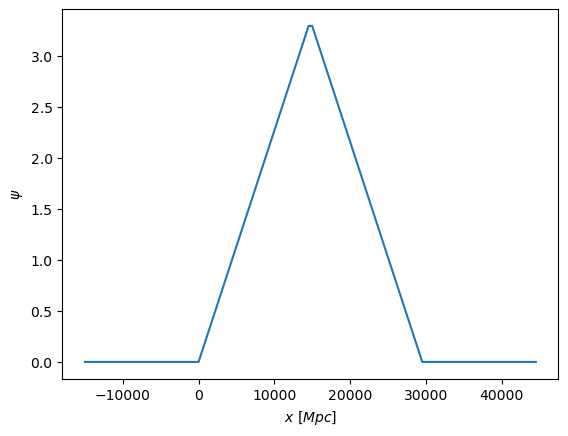

In [43]:
from scipy.signal import windows

if not mirror:
    psi_i_x = A/r_H*(zz - x_c) + B/(r_H**2)*(zz - x_c)**2
else:
    psi_i_x = A/r_H*(zz_left - x_c) + B/(r_H**2)*(zz_left - x_c)**2
use_window = 0

if not mirror and not use_window:
    psi_i_x[np.where(zz<x_c)] = 0
if mirror:
    psi_i_x[np.where(zz_left<x_c)] = 0
    psi_i_x = np.concatenate((psi_i_x, np.flip(psi_i_x, axis=2)), axis=2)
    plt.plot(z, psi_i_x[0, 0, :])
    
    if use_window:
        def smooth_step(x, x_c, width):
            return 1 / (1 + np.exp(-(x - x_c) / width))   
         # Calculate the smooth transition mask
        smooth_mask_1 = smooth_step(zz, x_c, 500)
        # smooth_mask_2 = smooth_step(zz, BoxSize/2, 500)
        plt.plot(z, smooth_mask_1[0, 0, :])
        # plt.plot(z, smooth_mask_2[0, 0, :])

         # Apply the smooth transition to psi_i_x
        psi_i_x *= smooth_mask_1
        plt.plot(z, psi_i_x[0, 0, :])


# if use_window:
#     window_type = 'gaussian'
#     if window_type == 'hann':
#         wz = windows.hann(2*grid)
#     elif window_type == 'gaussian':
#         wz = windows.gaussian(2*grid, std=grid)
#     window = wz[np.newaxis,np.newaxis,:]
#     psi_i_x = (window*psi_i_x)


# else:  # yg debug
#     def smooth_step(x, x_c, width):
#         return 1 / (1 + np.exp(-(x - x_c) / width))

#     # Calculate the smooth transition mask
#     smooth_mask = smooth_step(zz, x_c, 500)

#     # Apply the smooth transition to psi_i_x
#     psi_i_x *= smooth_mask


# if use_window:
#     window_type = 'gaussian'
#     if window_type == 'hann':
#         wz = windows.hann(grid)
#     elif window_type == 'gaussian':
#         wz = windows.gaussian(grid, std=grid/12)
#     print(wz)
#     window = wz[np.newaxis,np.newaxis,:]
# else:
#     window = 1

# plt.plot(z, (window*psi_i_x)[0, 0, :])

# print(direction)
# if direction == 'x':
#     plt.plot(x,psi_i_x[:, 0, 0])

# elif direction == 'y':
#     plt.plot(x,psi_i_x[0, :, 0])

# elif direction == 'z':
#     plt.plot(z, (window*psi_i_x)[0, 0, :])

plt.xlabel(r'$x\ [Mpc]$')
plt.ylabel(r'$\psi$')

In [44]:
if 0:
    fig = plt.figure()
    ax = fig.add_subplot(111, projection='3d')
    
    fig.colorbar(ax.scatter(xx,yy,zz,c=psi_i_x, s=0.01))
    ax.set_xlabel(r'x')
    ax.set_ylabel(r'y')
    ax.set_zlabel(r'z')
    ax.set_title(r'$\Psi_{i} (\mathbf{x})$');

# Choose the Ze of remote dipole field

In [45]:
r_e = rs.chifromz(Z_e)
r_edec = rs.chifromz(config.zdec) - rs.chifromz(Z_e)
r_dec = rs.chifromz(config.zdec)

print(f'r_c = {x_c} Mpc')
print(f'r_e = {r_e} Mpc')
print(f'r_edec = {r_edec} Mpc')
print(f'r_dec = {r_dec} Mpc')
print(f'r_H = {r_H} Mpc')

r_c = 0.0 Mpc
r_e = 3383.0757390849803 Mpc
r_edec = 10457.99315186038 Mpc
r_dec = 13841.068890945362 Mpc
r_H = 4411.764705882353 Mpc


In [46]:
from my_remote_spectra import T, G_SW_ksz, G_localDopp_ksz, G_Dopp_ksz, G_ISW_ksz

In [47]:
do_gradient = False
if do_gradient:
    Edge_order=2   
    g_psi_i_x = np.array([np.gradient(psi_i_x, d, edge_order=Edge_order)[1], np.gradient(psi_i_x, d, edge_order=Edge_order)[0], np.gradient(psi_i_x, d, edge_order=Edge_order)[2]])
#     g_psi_i_x = np.array([np.gradient(psi_i_x, d, edge_order=Edge_order)[0], np.gradient(psi_i_x, d, edge_order=Edge_order)[1], np.gradient(psi_i_x, d, edge_order=Edge_order)[2]])

else:
    g_psi_i_x3 = A/r_H + 2*B/(r_H**2)*(zz - x_c)
    g_psi_i_x3[np.where(zz<x_c)] = 0
    g_psi_i_x = np.array([np.zeros(xx.shape), np.zeros(xx.shape), g_psi_i_x3])

if 1:
    g_psi_i_k = np.array([np.fft.fftn(g_psi_i_x[0]), np.fft.fftn(g_psi_i_x[1]), np.fft.fftn(g_psi_i_x[2])])
else: # yg debug
    g_psi_i_k = np.array([psi_i_k * kk_x*1j, psi_i_k*kk_y*1j, psi_i_k * kk_z*1j])

In [48]:
if 0:
    print(direction)
    if direction == 'x':
        plt.plot(x,g_psi_i_x[0].real[0, :, 0]) 
    elif direction == 'y':
        plt.plot(x,g_psi_i_x[1].real[:, 0, 0]) 
    elif direction == 'z':
        # V_eff_SW_x3.real = np.abs(V_eff_SW_x3.real)
        plt.plot(z,g_psi_i_x[2].real[0, 0, :])
#         plt.plot(x,np.abs(g_psi_i_k[2])[0, 0, :])
#         plt.plot(x,np.abs(psi_i_k[2]*kk_z)[0, 0, :])


#         print(g_psi_i_x[2].real[0, 0, :])
    
    plt.title(r'$\nabla_i\Psi_{i} (\mathbf{x}), A=%s, B=%s, Z_{c}=%s$'%(A, B, z_c));
    plt.xlabel(r'$x\ [Mpc]$')
    plt.ylabel(r'$v/c$', rotation=0)

(-15000.0, 15000.0)

(-15000.0, 15000.0)

(-15000.0, 15000.0)

Text(0.5, 0, 'x [Mpc]')

Text(0.5, 0.5, 'y [Mpc]')

Text(0.5, 0, 'z [Mpc]')

Text(0.5, 0.92, '$V_{eff, r}(\\mathbf{x}, r_e), A=1, B=0, Z_{c}=0, Z_{e}=1$')

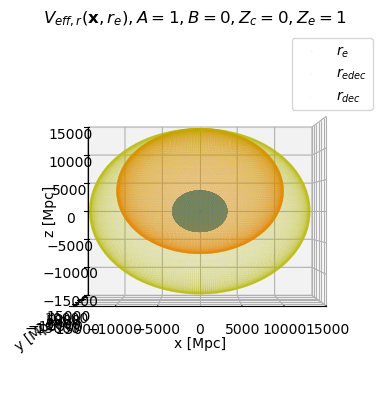

In [49]:
# try to plot the sphere on heapix plot
# https://healpy.readthedocs.io/en/latest/tutorial.html
NSIDE = 64
NPIX = hp.nside2npix(NSIDE)

theta_deg, phi_deg = np.degrees(hp.pix2ang(nside=NSIDE, ipix=np.arange(NPIX)))
theta = theta_deg * pi / 180.0
phi = phi_deg * pi / 180.0

x_e = r_e*np.sin(theta)*np.cos(phi) #Mpc
y_e = r_e*np.sin(theta)*np.sin(phi) #Mpc
z_e = r_e*np.cos(theta) #Mpc

if 0:
    fig = plt.figure()
    ax = fig.add_subplot(projection='3d')

    ax.scatter(x_e,y_e,z_e, s=0.2)
    # ax.set_xlim([-r_o, r_o])
    # ax.set_ylim([-r_o, r_o])
    # ax.set_zlim([-r_o, r_o])
    ax.set_xlabel(r'x')
    ax.set_ylabel(r'y')
    ax.set_zlabel(r'z')
    # ax.view_init(90, -90) 

# see https://stackoverflow.com/questions/11140163/plotting-a-3d-cube-a-sphere-and-a-vector and \
# https://stackoverflow.com/questions/64656951/plotting-spheres-of-radius-r
# check https://stackoverflow.com/questions/11140163/plotting-a-3d-cube-a-sphere-and-a-vector
# Z_e = 2
# a_e = 1/(1+Z_e)
# firstly obtain all the points at r_e = tau(a=1)-tau(a=a_e)
fig = plt.figure()
ax = fig.add_subplot(projection='3d')

# then plot the LSS for an electron at this sphere and the LSS for us
# pick a certain point at the sphere with coordinate of (a_e, x_e, y_e, z_e)

x_edec_s = r_edec*np.sin(theta)*np.cos(phi)
y_edec_s = r_edec*np.sin(theta)*np.sin(phi)
z_edec_s = r_edec*np.cos(theta)
# ax.scatter(x_e,y_e,z_e, color='r', s=10)

# get r_dec
# u, v = np.mgrid[0:2*np.pi:20j, 0:np.pi:20j]
x_dec_s = r_dec*np.sin(theta)*np.cos(phi)
y_dec_s = r_dec*np.sin(theta)*np.sin(phi)
z_dec_s = r_dec*np.cos(theta)

if 1:
    ax.scatter(x_e, y_e, z_e, alpha=0.4, label=r'$r_{e}$', s=0.01)
    ax.scatter(x_edec_s+x_e[0], y_edec_s+y_e[0], z_edec_s+z_e[0], alpha=0.4, label=r'$r_{edec}$', s=0.01)
    ax.scatter(x_dec_s, y_dec_s, z_dec_s, color='y', alpha=0.4, label=r'$r_{dec}$', s=0.01)
    ax.scatter(0,0,0, color='k', s=1)
    ax.scatter(x_e[0],y_e[0],z_e[0], color='r', s=2)
    
    if mirror:
        yy_c, zz_c = np.meshgrid(y, z_left)
    else:
        yy_c, zz_c = np.meshgrid(y, z)
    yy_c, zz_c = np.meshgrid(y, z)
    xx_c = x_c*np.ones_like(yy_c)
    if direction == 'x':
        ax.plot_surface(xx_c, yy_c, zz_c, alpha=0.2)
    if direction == 'y':
        ax.plot_surface(yy_c, xx_c, zz_c, alpha=0.2)
    elif direction == 'z':
        ax.plot_surface(yy_c, zz_c, xx_c, alpha=0.2)
    
    ax.set_xlim([-BoxSize/2, BoxSize/2])
    ax.set_ylim([-BoxSize/2, BoxSize/2])
    ax.set_zlim([-BoxSize/2,BoxSize/2])
    ax.set_xlabel(r'x [Mpc]')
    ax.set_ylabel(r'y [Mpc]')
    ax.set_zlabel(r'z [Mpc]')
    ax.set_title(r'$V_{eff, r}(\mathbf{x}, r_e), A=%s, B=%s, Z_{c}=%s, Z_{e}=%s$'%(A, B, z_c, Z_e))
    ax.legend()
    ax.view_init(0, -90) 

In [50]:
import my_tools
importlib.reload(my_tools)
from my_tools import Evolve

EV = Evolve(kk, Z_e, Omega_b, Omega_c, w, wa, Omega_K, h, use_transfer=False)
use_GradientEvolve = False
# if 1: use_GradientEvolve = False  # yg debug


if use_GradientEvolve:
    RDF_localDopp_3d = EV.RDF_g_Evolve('localDopp', g_psi_i_k)
    RDF_decDopp_3d = EV.RDF_g_Evolve('decDopp', g_psi_i_k)
    RDF_Dopp_3d = EV.RDF_g_Evolve('Dopp', g_psi_i_k)
    RDF_SW_3d = EV.RDF_g_Evolve('SW', g_psi_i_k)
    RDF_ISW_3d = EV.RDF_g_Evolve('ISW', g_psi_i_k)
    
else:
    psi_i_k = np.fft.fftn(psi_i_x)
    RDF_localDopp_3d = EV.RDF_Evolve('localDopp', psi_i_k, [kk_x, kk_y, kk_z])
    RDF_decDopp_3d = EV.RDF_Evolve('decDopp', psi_i_k, [kk_x, kk_y, kk_z])
    RDF_Dopp_3d = EV.RDF_Evolve('Dopp', psi_i_k, [kk_x, kk_y, kk_z])
    RDF_SW_3d = EV.RDF_Evolve('SW', psi_i_k, [kk_x, kk_y, kk_z])
    RDF_ISW_3d = EV.RDF_Evolve('ISW', psi_i_k, [kk_x, kk_y, kk_z])
    RDF_total_3d = EV.RDF_Evolve('total', psi_i_k, [kk_x, kk_y, kk_z])


<module 'my_tools' from '/home/hongbo/tools/ReCCO/code/my_tools.py'>

/home/hongbo/tools/ReCCO/code/my_tools.py:64: RuntimeWarning: invalid value encountered in divide
  factor_x = 1j*kk_component[0]/self.kk
/home/hongbo/tools/ReCCO/code/my_tools.py:66: RuntimeWarning: invalid value encountered in divide
  factor_y = 1j*kk_component[1]/self.kk
/home/hongbo/tools/ReCCO/code/my_tools.py:68: RuntimeWarning: invalid value encountered in divide
  factor_z = 1j*kk_component[2]/self.kk


In [51]:
if 0:
    a_dec = kszpsz_config.adec
    D_psi_dec = rs.Dpsi_inter(Omega_b, Omega_c, w, wa, Omega_K, h)(a_dec)
    D_psi_e = rs.Dpsi_inter(Omega_b, Omega_c, w, wa, Omega_K, h)(a_e)
    print(D_psi_dec)
    print(D_psi_e)
    
    
    plt.plot(z, RDF_SW_3d[2].real[0, 0, :], label='SW')
    plt.plot(z, RDF_ISW_3d[2].real[0, 0, :], label='ISW')
    plt.title(r'$V_{eff,z}(\mathbf{x}, r_e), A=%s, B=%s, Z_{c}=%s, Z_{e}=%s$'%(A, B, z_c, Z_e));
    plt.xlabel(r'$x\ [Mpc]$')
    plt.ylabel(r'$v/c$', rotation=0)

Text(0.5, 1.0, '$V^{localDopp}_{eff,z}(\\mathbf{x}, r_e), A=1, B=0, Z_{c}=0, Z_{e}=1$')

Text(0.5, 0, '$x\\ [Mpc]$')

Text(0, 0.5, '$v/c$')

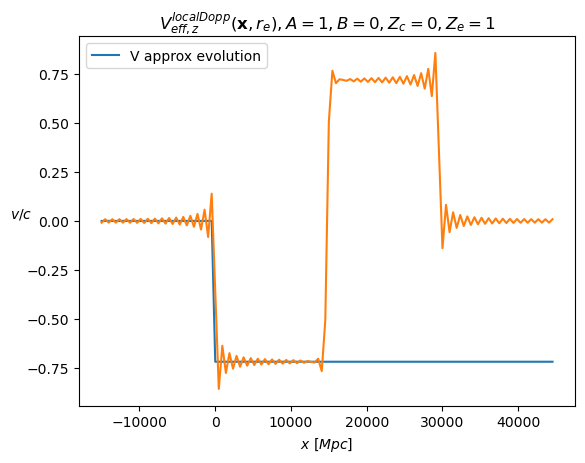

In [52]:
D_v = rs.Dv_inter(Omega_b, Omega_c, w, wa, Omega_K, h)(a_e)
plt.plot(z,-g_psi_i_x[2][0, 0, :]*D_v, label='V approx evolution')

plt.plot(z, RDF_localDopp_3d[2].real[0, 0, :])
plt.title(r'$V^{localDopp}_{eff,z}(\mathbf{x}, r_e), A=%s, B=%s, Z_{c}=%s, Z_{e}=%s$'%(A, B, z_c, Z_e));
plt.legend()
plt.xlabel(r'$x\ [Mpc]$')
plt.ylabel(r'$v/c$', rotation=0)

In [53]:
# see https://stackoverflow.com/questions/11140163/plotting-a-3d-cube-a-sphere-and-a-vector and \
# https://stackoverflow.com/questions/64656951/plotting-spheres-of-radius-r
# check https://stackoverflow.com/questions/11140163/plotting-a-3d-cube-a-sphere-and-a-vector
if 0:
    fig = plt.figure()
    ax = fig.add_subplot(projection='3d')
    
    # then plot the LSS for an electron at this sphere and the LSS for us
    # pick a certain point at the sphere with coordinate of (a_e, x_e, y_e, z_e)
    
    ax.scatter(x_e, y_e, z_e, c=RDF_SW_2d_radial, alpha=0.4, label=r'$r_{e}$', s=0.01)
    ax.scatter(x_edec_s+x_e[0], y_edec_s+y_e[0], z_edec_s+z_e[0], alpha=0.4, label=r'$r_{edec}$', s=0.01)
    ax.scatter(x_dec_s, y_dec_s, z_dec_s, color='y', alpha=0.4, label=r'$r_{dec}$', s=0.01)
    ax.scatter(0,0,0, color='k', s=1)
    ax.scatter(x_e[0],y_e[0],z_e[0], color='r', s=2)
    
    if mirror:
        yy_c, zz_c = np.meshgrid(y, z_left)
    else:
        yy_c, zz_c = np.meshgrid(y, z)
    xx_c = x_c*np.ones_like(yy_c)
    if direction == 'x':
        ax.plot_surface(xx_c, yy_c, zz_c, alpha=0.2)
    if direction == 'y':
        ax.plot_surface(yy_c, xx_c, zz_c, alpha=0.2)
    elif direction == 'z':
        ax.plot_surface(yy_c, zz_c, xx_c, alpha=0.2)
    
    ax.set_xlim([-BoxSize/2, BoxSize/2])
    ax.set_ylim([-BoxSize/2, BoxSize/2])
    ax.set_zlim([-BoxSize/2,BoxSize/2])
    ax.set_xlabel(r'x [Mpc]')
    ax.set_ylabel(r'y [Mpc]')
    ax.set_zlabel(r'z [Mpc]')
    ax.set_title(r'$V_{eff, r}(\mathbf{x}, r_e), A=%s, B=%s, Z_{c}=%s, Z_{e}=%s$'%(A, B, z_c, Z_e))
    ax.legend()
    ax.view_init(0, -90) 

In [54]:
# check https://stackoverflow.com/questions/11140163/plotting-a-3d-cube-a-sphere-and-a-vector
if 0:
    print(direction)
    fig = plt.figure()
    ax = fig.add_subplot(projection='3d')
    fig.colorbar(ax.scatter(x_e, y_e, z_e, c=RDF_localDopp_2d[2], alpha=0.4, label=r'$r_{edec}$', s=0.2))
    # fig.colorbar(ax.scatter(x_e, y_e, z_e, c=V_eff_SW_radial_chi, alpha=0.4, label=r'$r_{edec}$', s=0.2));
    # ax.scatter(x_e,y_e,z_e, color='r', s=10)
    ax.set_xlabel(r'x [Mpc]')
    ax.set_ylabel(r'y [Mpc]')
    ax.set_zlabel(r'z [Mpc]')
    ax.set_title(r'$V^{localDopp}_{eff, z}(\mathbf{x}, r_e), A=%s, B=%s, Z_{c}=%s, Z_{e}=%s$'%(A, B, z_c, Z_e));
    
    # check xy direction np.cos(theta)view
    # ax.view_init(0, -90) 
    # ax.view_init(90, -90) 
    # ==========   ====  ====
    # view plane   elev  azim
    # ==========   ====  ====
    # XY           90    -90
    # XZ           0     -90
    # YZ           0     0
    # -XY          -90   90
    # -XZ          0     90
    # -YZ          0     180
    # ==========   ====  ====

In [55]:
# check https://stackoverflow.com/questions/11140163/plotting-a-3d-cube-a-sphere-and-a-vector
if 0:
    print(direction)
    fig = plt.figure()
    ax = fig.add_subplot(projection='3d')
    fig.colorbar(ax.scatter(x_e, y_e, z_e, c=RDF_localDopp_2d_radial, alpha=0.4, label=r'$r_{edec}$', s=0.2))
    ax.set_xlabel(r'x [Mpc]')
    ax.set_ylabel(r'y [Mpc]')
    ax.set_zlabel(r'z [Mpc]')
    ax.set_title(r'$V^{localDopp}_{eff, r}(\mathbf{x}, r_e), A=%s, B=%s, Z_{c}=%s, Z_{e}=%s$'%(A, B, z_c, Z_e));

# Check 1D symmetries

In [56]:
theta_e_deg_1d = np.arange(0,181,1)
phi_e_deg_1d = 0
    
theta_e_1d = theta_e_deg_1d * pi / 180.0
phi_e_1d = phi_e_deg_1d * pi / 180.0
    
x_e_1d = r_e*np.sin(theta_e_1d)*np.cos(phi_e_1d)
y_e_1d = r_e*np.sin(theta_e_1d)*np.sin(phi_e_1d)
z_e_1d = r_e*np.cos(theta_e_1d)


RDF_localDopp_1d = EV.ThreeDVec_Projection((x, y, z), RDF_localDopp_3d.real, (x_e_1d, y_e_1d, z_e_1d))
RDF_decDopp_1d = EV.ThreeDVec_Projection((x, y, z), RDF_decDopp_3d.real, (x_e_1d, y_e_1d, z_e_1d))
RDF_Dopp_1d = EV.ThreeDVec_Projection((x, y, z), RDF_Dopp_3d.real, (x_e_1d, y_e_1d, z_e_1d))
RDF_SW_1d = EV.ThreeDVec_Projection((x, y, z), RDF_SW_3d.real, (x_e_1d, y_e_1d, z_e_1d))
RDF_ISW_1d = EV.ThreeDVec_Projection((x, y, z), RDF_ISW_3d.real, (x_e_1d, y_e_1d, z_e_1d))
RDF_total_1d = EV.ThreeDVec_Projection((x, y, z), RDF_total_3d.real, (x_e_1d, y_e_1d, z_e_1d))

RDF_localDopp_1d_radial = EV.ThreeDVec_Projection_Radial((x, y, z), RDF_localDopp_3d.real, (x_e_1d, y_e_1d, z_e_1d), (theta_e_1d, phi_e_1d))
RDF_decDopp_1d_radial = EV.ThreeDVec_Projection_Radial((x, y, z), RDF_decDopp_3d.real, (x_e_1d, y_e_1d, z_e_1d), (theta_e_1d, phi_e_1d))
RDF_Dopp_1d_radial = EV.ThreeDVec_Projection_Radial((x, y, z), RDF_Dopp_3d.real, (x_e_1d, y_e_1d, z_e_1d), (theta_e_1d, phi_e_1d))
RDF_SW_1d_radial = EV.ThreeDVec_Projection_Radial((x, y, z), RDF_SW_3d.real, (x_e_1d, y_e_1d, z_e_1d), (theta_e_1d, phi_e_1d))
RDF_ISW_1d_radial = EV.ThreeDVec_Projection_Radial((x, y, z), RDF_ISW_3d.real, (x_e_1d, y_e_1d, z_e_1d), (theta_e_1d, phi_e_1d))
RDF_total_1d_radial = EV.ThreeDVec_Projection_Radial((x, y, z), RDF_total_3d.real, (x_e_1d, y_e_1d, z_e_1d), (theta_e_1d, phi_e_1d))

<module 'bubble_collision' from '/home/hongbo/tools/ReCCO/code/bubble_collision.py'>

Text(0.5, 0, '$\\theta\\ [deg]$')

Text(0, 0.5, '$v_{eff, r}/c$')

Text(0.5, 1.0, '$A=1, B=0, Z_{c}=0, Z_{e}=1$')

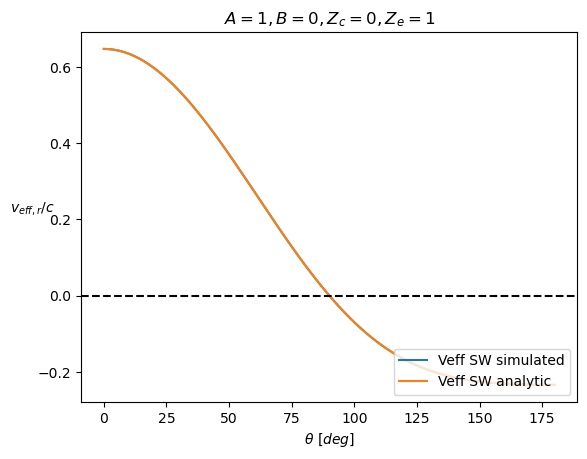

In [57]:
import bubble_collision as bc
importlib.reload(bc)

BC = bc.BubbleCollision_RF(A, B, z_c, Z_e, Omega_b, Omega_c, w, wa, Omega_K, h)

plt.plot(theta_e_deg_1d, RDF_SW_1d_radial, label='Veff SW simulated')
plt.plot(theta_e_deg_1d, BC.Approx_RDF_SW_radial(theta_e_1d), label='Veff SW analytic')
plt.xlabel(r'$\theta\ [deg]$')
plt.ylabel(r'$v_{eff, r}/c$', rotation=0)
plt.legend(loc='lower right')
plt.axhline(y=0, c='k', linestyle='--')
plt.title(r'$A=%s, B=%s, Z_{c}=%s, Z_{e}=%s$'%(A, B, z_c, Z_e))

Text(0.5, 0, '$\\theta\\ [deg]$')

Text(0, 0.5, '$v_{eff, r}/c$')

Text(0.5, 1.0, '$A=1, B=0, Z_{c}=0, Z_{e}=1$')

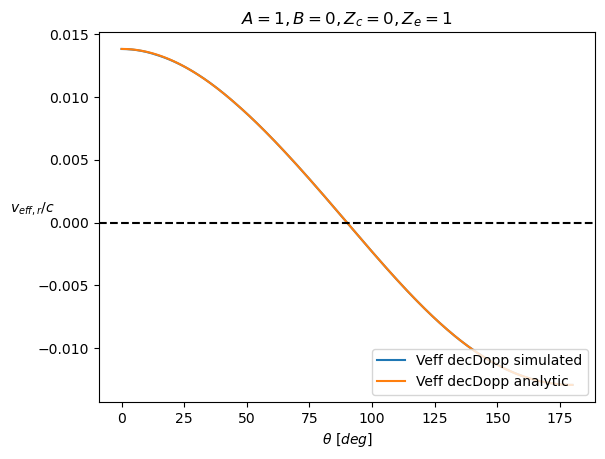

In [58]:
plt.plot(theta_e_deg_1d, RDF_decDopp_1d_radial, label='Veff decDopp simulated')
plt.plot(theta_e_deg_1d, BC.Approx_RDF_decDopp_radial(theta_e_1d), label='Veff decDopp analytic')
plt.xlabel(r'$\theta\ [deg]$')
plt.ylabel(r'$v_{eff, r}/c$', rotation=0)
plt.legend(loc='lower right')
plt.axhline(y=0, c='k', linestyle='--')
plt.title(r'$A=%s, B=%s, Z_{c}=%s, Z_{e}=%s$'%(A, B, z_c, Z_e))

<module 'bubble_collision' from '/home/hongbo/tools/ReCCO/code/bubble_collision.py'>

/home/hongbo/tools/ReCCO/code/bubble_collision.py:88: RuntimeWarning: divide by zero encountered in divide
  cos_theta_c = (self.chi_c -self.chi_e*cos_theta_e)/chi_edec


Text(0.5, 0, '$\\theta\\ [deg]$')

Text(0, 0.5, '$v_{eff, r}/c$')

Text(0.5, 1.0, '$A=1, B=0, Z_{c}=0, Z_{e}=1$')

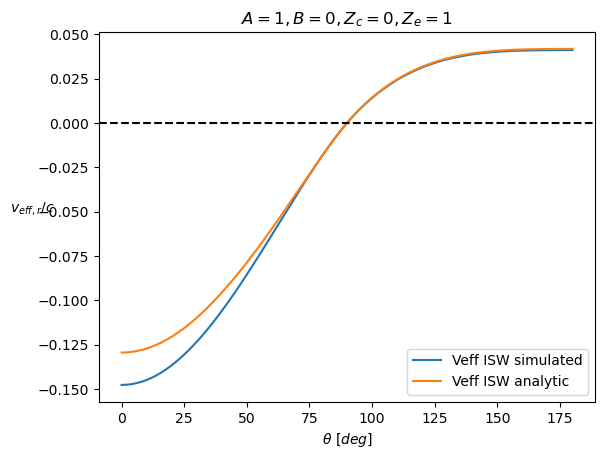

In [59]:
import bubble_collision as bc
importlib.reload(bc)
BC = bc.BubbleCollision_RF(A, B, z_c, Z_e, Omega_b, Omega_c, w, wa, Omega_K, h)

plt.plot(theta_e_deg_1d, RDF_ISW_1d_radial, label='Veff ISW simulated')
plt.plot(theta_e_deg_1d, BC.Approx_RDF_ISW_radial(theta_e_1d), label='Veff ISW analytic')
plt.xlabel(r'$\theta\ [deg]$')
plt.ylabel(r'$v_{eff, r}/c$', rotation=0)
plt.legend(loc='lower right')
plt.axhline(y=0, c='k', linestyle='--')
plt.title(r'$A=%s, B=%s, Z_{c}=%s, Z_{e}=%s$'%(A, B, z_c, Z_e))
# a = np.logspace(np.log10(config.adec), np.log10(rs.az(Z_e)), kszpsz_config.transfer_integrand_sampling)
# print(a)

Text(0.5, 0, '$\\theta\\ [deg]$')

Text(0, 0.5, '$v_{eff, r}/c$')

Text(0.5, 1.0, '$A=1, B=0, Z_{c}=0, Z_{e}=1$')

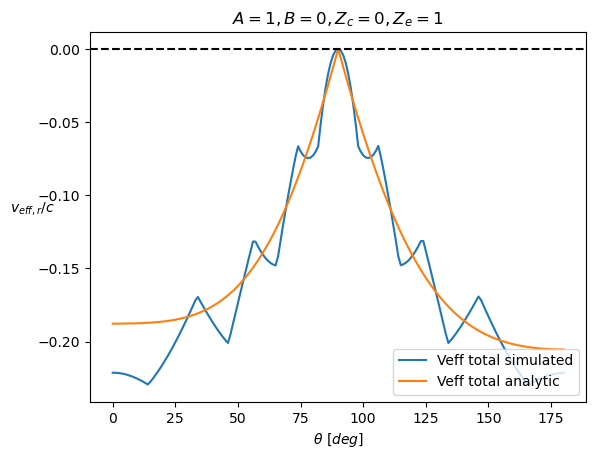

In [60]:
plt.plot(theta_e_deg_1d, RDF_total_1d_radial, label='Veff total simulated')
plt.plot(theta_e_deg_1d, BC.Approx_RDF_radial(theta_e_1d), label='Veff total analytic')
plt.xlabel(r'$\theta\ [deg]$')
plt.ylabel(r'$v_{eff, r}/c$', rotation=0)
plt.legend(loc='lower right')
plt.axhline(y=0, c='k', linestyle='--')
plt.title(r'$A=%s, B=%s, Z_{c}=%s, Z_{e}=%s$'%(A, B, z_c, Z_e))

<Figure size 800x600 with 0 Axes>

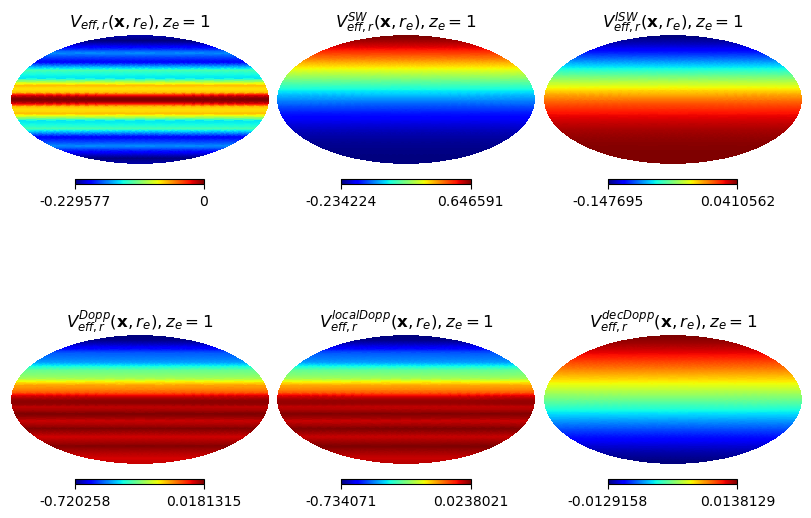

In [61]:
if 1:
    if 0:
        RDF_localDopp_2d = EV.ThreeDVec_Projection((x, y, z), RDF_localDopp_3d.real, (x_e, y_e, z_e))
        RDF_decDopp_2d = EV.ThreeDVec_Projection((x, y, z), RDF_decDopp_3d.real, (x_e, y_e, z_e))
        RDF_Dopp_2d = EV.ThreeDVec_Projection((x, y, z), RDF_Dopp_3d.real, (x_e, y_e, z_e))
        RDF_SW_2d = EV.ThreeDVec_Projection((x, y, z), RDF_SW_3d.real, (x_e, y_e, z_e))
        RDF_ISW_2d = EV.ThreeDVec_Projection((x, y, z), RDF_ISW_3d.real, (x_e, y_e, z_e))
        RDF_total_2d = EV.ThreeDVec_Projection((x, y, z), RDF_total_3d.real, (x_e, y_e, z_e))

    RDF_localDopp_2d_radial = EV.ThreeDVec_Projection_Radial((x, y, z), RDF_localDopp_3d.real, (x_e, y_e, z_e), (theta, phi))
    RDF_decDopp_2d_radial = EV.ThreeDVec_Projection_Radial((x, y, z), RDF_decDopp_3d.real, (x_e, y_e, z_e), (theta, phi))
    RDF_Dopp_2d_radial = EV.ThreeDVec_Projection_Radial((x, y, z), RDF_Dopp_3d.real, (x_e, y_e, z_e), (theta, phi))
    RDF_SW_2d_radial = EV.ThreeDVec_Projection_Radial((x, y, z), RDF_SW_3d.real, (x_e, y_e, z_e), (theta, phi))
    RDF_ISW_2d_radial = EV.ThreeDVec_Projection_Radial((x, y, z), RDF_ISW_3d.real, (x_e, y_e, z_e), (theta, phi))
    RDF_total_2d_radial = EV.ThreeDVec_Projection_Radial((x, y, z), RDF_total_3d.real, (x_e, y_e, z_e), (theta, phi))
    
    plt.figure(figsize=(8,6))
    hp.mollview(RDF_total_2d_radial, cmap="jet", xsize=800, sub=231, title=r'$V_{eff, r}(\mathbf{x}, r_e), z_e = %s$'%Z_e)
    hp.mollview(RDF_SW_2d_radial, cmap="jet", xsize=800, sub=232, title=r'$V^{SW}_{eff, r}(\mathbf{x}, r_e), z_e = %s$'%Z_e)
    hp.mollview(RDF_ISW_2d_radial, cmap="jet", xsize=800, sub=233, title=r'$V^{ISW}_{eff, r}(\mathbf{x}, r_e), z_e = %s$'%Z_e)
    hp.mollview(RDF_Dopp_2d_radial, cmap="jet", xsize=800, sub=234, title=r'$V^{Dopp}_{eff, r}(\mathbf{x}, r_e), z_e = %s$'%Z_e)
    hp.mollview(RDF_localDopp_2d_radial, cmap="jet", xsize=800, sub=235, title=r'$V^{localDopp}_{eff, r}(\mathbf{x}, r_e), z_e = %s$'%Z_e)
    hp.mollview(RDF_decDopp_2d_radial, cmap="jet", xsize=800, sub=236, title=r'$V^{decDopp}_{eff, r}(\mathbf{x}, r_e), z_e = %s$'%Z_e)

# Remote Quadrupole Field (RQF)

In [62]:
import my_tools
importlib.reload(my_tools)
from my_tools import Evolve

EV = Evolve(kk, Z_e, Omega_b, Omega_c, w, wa, Omega_K, h)
RQF_Dopp_3d = EV.RQF_Evolve('Dopp', psi_i_k, [kk_x, kk_y, kk_z])
RQF_SW_3d = EV.RQF_Evolve('SW', psi_i_k, [kk_x, kk_y, kk_z])
RQF_ISW_3d = EV.RQF_Evolve('ISW', psi_i_k, [kk_x, kk_y, kk_z])
RQF_total_3d = EV.RQF_Evolve('total', psi_i_k, [kk_x, kk_y, kk_z])

RQF_Dopp_1d_radial = EV.RQF_Projection_Radial((x, y, z), RQF_Dopp_3d.real, (x_e_1d, y_e_1d, z_e_1d), (theta_e_1d, phi_e_1d))
RQF_SW_1d_radial = EV.RQF_Projection_Radial((x, y, z), RQF_SW_3d.real, (x_e_1d, y_e_1d, z_e_1d), (theta_e_1d, phi_e_1d))
RQF_ISW_1d_radial = EV.RQF_Projection_Radial((x, y, z), RQF_ISW_3d.real, (x_e_1d, y_e_1d, z_e_1d), (theta_e_1d, phi_e_1d))
RQF_total_1d_radial = EV.RQF_Projection_Radial((x, y, z), RQF_total_3d.real, (x_e_1d, y_e_1d, z_e_1d), (theta_e_1d, phi_e_1d))

<module 'my_tools' from '/home/hongbo/tools/ReCCO/code/my_tools.py'>

/home/hongbo/tools/ReCCO/code/my_tools.py:85: RuntimeWarning: invalid value encountered in divide
  factor = 1/4*np.sqrt(5/pi)*(3*kk_component[2]**2/self.kk**2 -1)


Text(0.5, 0, '$k\\ [1/Mpc]$')

Text(0.5, 1.0, '$RDF, z_{e}=1$')

Text(0.5, 0, '$k\\ [1/Mpc]$')

Text(0.5, 1.0, '$RQF, z_{e}=1$')

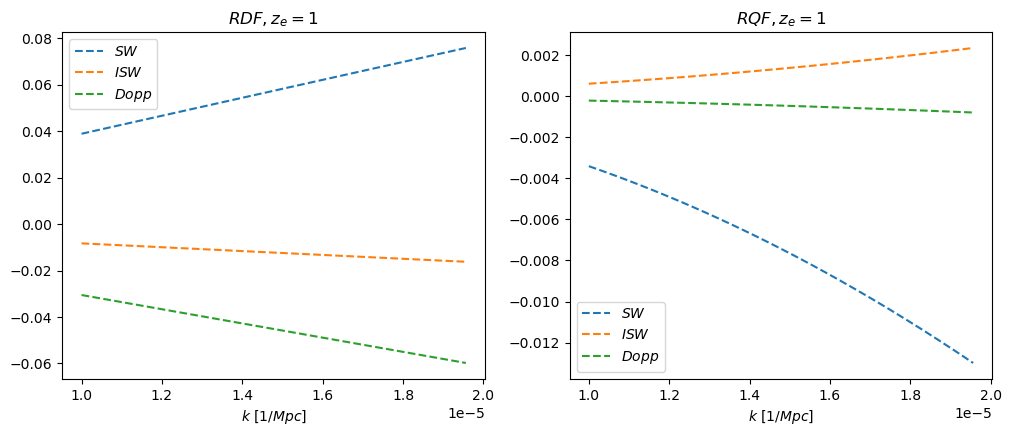

In [63]:
# plot RDF and RQF fourier kernels
if 1:
    # sampling k modes
    ks = kszpsz_config.kaux #1/Mpc
    # ks = np.linspace(1e-6, 4e-2, 1000)
    use_transfer = 0
    if use_transfer:
        T = rs.T(ks, Omega_b, Omega_c, w, wa, Omega_K, h)
    else:
        T = 1
    G_RDF_SW = rs.G_SW_ksz(ks, Z_e, Omega_b, Omega_c, w, wa, Omega_K, h)
    G_RDF_ISW = rs.G_ISW_ksz(ks, Z_e, Omega_b, Omega_c, w, wa, Omega_K, h)
    G_RDF_localDopp = rs.G_localDopp_ksz(ks, Z_e, Omega_b, Omega_c, w, wa, Omega_K, h)
    G_RDF_decDopp = rs.G_decDopp_ksz(ks, Z_e, Omega_b, Omega_c, w, wa, Omega_K, h)
    G_RDF_Dopp = rs.G_Dopp_ksz(ks, Z_e, Omega_b, Omega_c, w, wa, Omega_K, h)
    G_RDF = rs.G_ksz(ks, Omega_b, Z_e, Omega_c, w, wa, Omega_K, h)
    
    G_RQF_SW = rs.G_SW_psz(ks, Z_e, Omega_b, Omega_c, w, wa, Omega_K, h)
    G_RQF_ISW = rs.G_ISW_psz(ks, Z_e, Omega_b, Omega_c, w, wa, Omega_K, h)
    G_RQF_decDopp = rs.G_Dopp_psz(ks, Z_e, Omega_b, Omega_c, w, wa, Omega_K, h)
    G_RQF = rs.G_psz(ks, Omega_b, Z_e, Omega_c, w, wa, Omega_K, h)

    num_k_max = 30
    fig, ax = plt.subplots(1, 2,figsize=(6*2,4.5*1))
    # ax[0].plot(x, psi_i_test, label=r'$\psi_i$')
    # ax[0].plot(ks[:num_k_max], (G_RDF_Dopp + G_RDF_SW)[:num_k_max], '--', label=r'$Dopp + SW$')
    ax[0].plot(ks[:num_k_max], G_RDF_SW[:num_k_max], '--', label=r'$SW$')
    ax[0].plot(ks[:num_k_max], G_RDF_ISW[:num_k_max], '--', label=r'$ISW$')
    ax[0].plot(ks[:num_k_max], G_RDF_Dopp[:num_k_max], '--', label=r'$Dopp$')
    ax[0].set_xlabel(r'$k\ [1/Mpc]$')
    ax[0].set_title(r'$RDF, z_{e}=%s$' %Z_e)
    ax[0].legend()

    # ax[1].plot(ks[:num_k_max], (G_RQF_decDopp + G_RQF_SW)[:num_k_max], '--', label=r'$Dopp + SW$')
    ax[1].plot(ks[:num_k_max], G_RQF_SW[:num_k_max], '--', label=r'$SW$')
    ax[1].plot(ks[:num_k_max], G_RQF_ISW[:num_k_max], '--', label=r'$ISW$')
    ax[1].plot(ks[:num_k_max], G_RQF_decDopp[:num_k_max], '--', label=r'$Dopp$')
    ax[1].set_xlabel(r'$k\ [1/Mpc]$')
    ax[1].set_title(r'$RQF, z_{e}=%s$' %Z_e)
    ax[1].legend()

In [64]:
if 0:
    num_k_max = 30
    plt.plot(ks[:num_k_max], (G_Dopp_Veff + G_SW_Veff)[:num_k_max], '--', label=r'$Dopp + SW$')
    # plt.plot(ks, G_SW_Veff_w0wa, '--', label=r'$SW\ w_{0}w_{a}$')
    
    plt.plot(ks[:num_k_max], G_ISW_Veff[:num_k_max], '--', label=r'$ISW$')
    # plt.plot(ks, G_ISW_Veff_w0wa, '-.', label=r'$ISW\ w_{0}w_{a}$')
    
    plt.axhline(y=0, linestyle = ':', c='k')
    plt.legend()
    plt.xlabel(r'$k$')
    plt.title(r'$Fourier\ kernel, z_{e}=%s$' %Z_e)
    plt.xlabel(r'$k[Mpc^{-1}]$')

Text(0.5, 0, '$\\theta\\ [deg]$')

Text(0, 0.5, '$q_{eff, r}/c$')

Text(0.5, 1.0, '$A=1, B=0, Z_{c}=0, Z_{e}=1$')

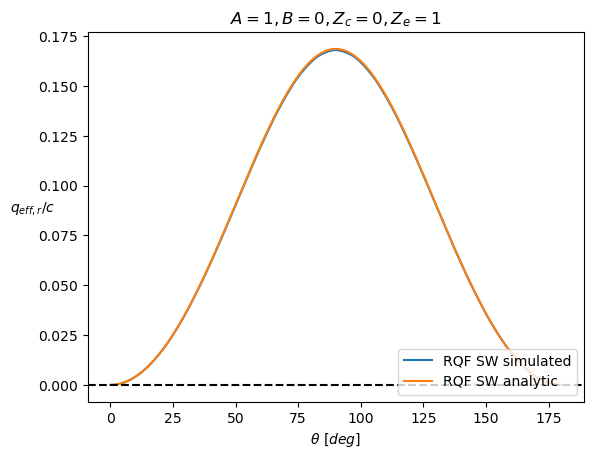

In [65]:
plt.plot(theta_e_deg_1d, RQF_SW_1d_radial, label='RQF SW simulated')
plt.plot(theta_e_deg_1d, BC.Approx_RQF_SW(theta_e_1d), label='RQF SW analytic')

plt.xlabel(r'$\theta\ [deg]$')
plt.ylabel(r'$q_{eff, r}/c$', rotation=0)
plt.legend(loc='lower right')
plt.axhline(y=0, c='k', linestyle='--')
plt.title(r'$A=%s, B=%s, Z_{c}=%s, Z_{e}=%s$'%(A, B, z_c, Z_e))

/home/hongbo/tools/ReCCO/code/bubble_collision.py:142: RuntimeWarning: divide by zero encountered in divide
  cos_theta_c = (self.chi_c -self.chi_e*cos_theta_e)/chi_edec


Text(0.5, 0, '$\\theta\\ [deg]$')

Text(0, 0.5, '$q_{eff, r}/c$')

Text(0.5, 1.0, '$A=1, B=0, Z_{c}=0, Z_{e}=1$')

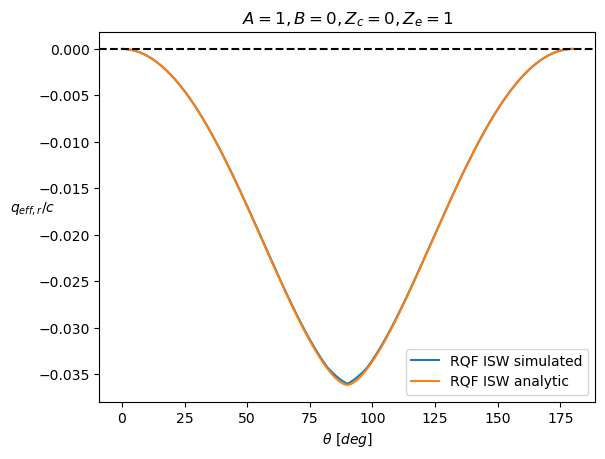

In [66]:
plt.plot(theta_e_deg_1d, RQF_ISW_1d_radial, label='RQF ISW simulated')
plt.plot(theta_e_deg_1d, BC.Approx_RQF_ISW(theta_e_1d), label='RQF ISW analytic')

plt.xlabel(r'$\theta\ [deg]$')
plt.ylabel(r'$q_{eff, r}/c$', rotation=0)
plt.legend(loc='lower right')
plt.axhline(y=0, c='k', linestyle='--')
plt.title(r'$A=%s, B=%s, Z_{c}=%s, Z_{e}=%s$'%(A, B, z_c, Z_e))

Text(0.5, 0, '$\\theta\\ [deg]$')

Text(0, 0.5, '$q_{eff, r}/c$')

Text(0.5, 1.0, '$A=1, B=0, Z_{c}=0, Z_{e}=1$')

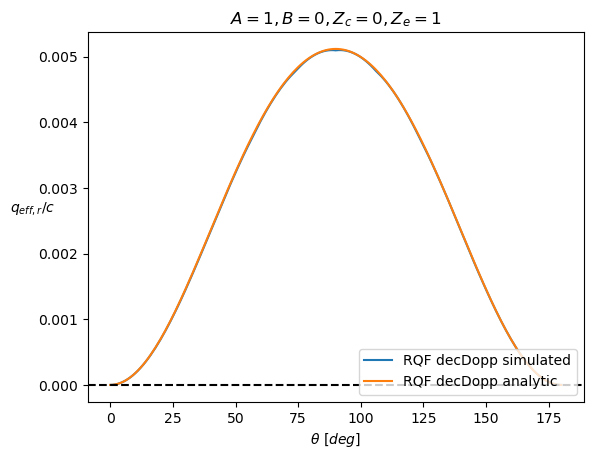

In [67]:
plt.plot(theta_e_deg_1d, RQF_Dopp_1d_radial, label='RQF decDopp simulated')
plt.plot(theta_e_deg_1d, BC.Approx_RQF_decDopp(theta_e_1d), label='RQF decDopp analytic')

plt.xlabel(r'$\theta\ [deg]$')
plt.ylabel(r'$q_{eff, r}/c$', rotation=0)
plt.legend(loc='lower right')
plt.axhline(y=0, c='k', linestyle='--')
plt.title(r'$A=%s, B=%s, Z_{c}=%s, Z_{e}=%s$'%(A, B, z_c, Z_e))

Text(0.5, 0, '$\\theta\\ [deg]$')

Text(0, 0.5, '$q_{eff, r}/c$')

Text(0.5, 1.0, '$A=1, B=0, Z_{c}=0, Z_{e}=1$')

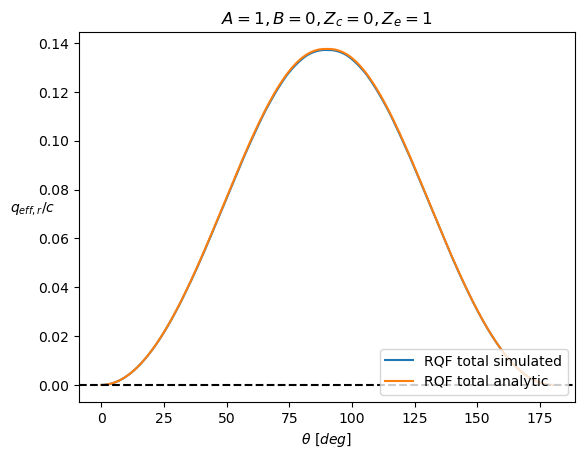

In [68]:
plt.plot(theta_e_deg_1d, RQF_total_1d_radial, label='RQF total simulated')
plt.plot(theta_e_deg_1d, BC.Approx_RQF(theta_e_1d), label='RQF total analytic')

plt.xlabel(r'$\theta\ [deg]$')
plt.ylabel(r'$q_{eff, r}/c$', rotation=0)
plt.legend(loc='lower right')
plt.axhline(y=0, c='k', linestyle='--')
plt.title(r'$A=%s, B=%s, Z_{c}=%s, Z_{e}=%s$'%(A, B, z_c, Z_e))

Text(0.5, 0, '$\\theta\\ [deg]$')

Text(0, 0.5, '$q_{eff, r}/c$')

Text(0.5, 1.0, '$A=1, B=0, Z_{c}=0, Z_{e}=1$')

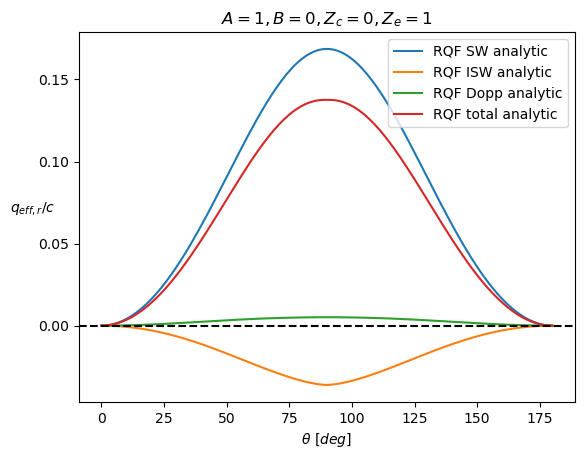

In [69]:
plt.plot(theta_e_deg_1d, BC.Approx_RQF_SW(theta_e_1d), label='RQF SW analytic')
plt.plot(theta_e_deg_1d, BC.Approx_RQF_ISW(theta_e_1d), label='RQF ISW analytic')
plt.plot(theta_e_deg_1d, BC.Approx_RQF_decDopp(theta_e_1d), label='RQF Dopp analytic')
plt.plot(theta_e_deg_1d, BC.Approx_RQF(theta_e_1d), label='RQF total analytic')

plt.xlabel(r'$\theta\ [deg]$')
plt.ylabel(r'$q_{eff, r}/c$', rotation=0)
plt.legend(loc='upper right')
plt.axhline(y=0, c='k', linestyle='--')
plt.title(r'$A=%s, B=%s, Z_{c}=%s, Z_{e}=%s$'%(A, B, z_c, Z_e))
plt.savefig('my_output/RQF_BubbleCollision.pdf', bbox_inches="tight")

<Figure size 800x600 with 0 Axes>

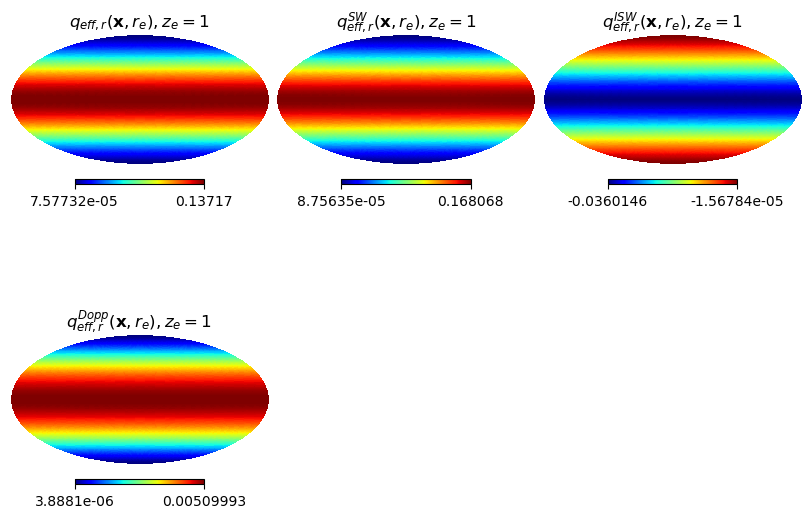

In [70]:
if 1:
    RQF_Dopp_2d_radial = EV.RQF_Projection_Radial((x, y, z), RQF_Dopp_3d.real, (x_e, y_e, z_e), (theta, phi))
    RQF_SW_2d_radial = EV.RQF_Projection_Radial((x, y, z), RQF_SW_3d.real, (x_e, y_e, z_e), (theta, phi))
    RQF_ISW_2d_radial = EV.RQF_Projection_Radial((x, y, z), RQF_ISW_3d.real, (x_e, y_e, z_e), (theta, phi))
    RQF_total_2d_radial = EV.RQF_Projection_Radial((x, y, z), RQF_total_3d.real, (x_e, y_e, z_e), (theta, phi))
    
    plt.figure(figsize=(8,6))
    hp.mollview(RQF_total_2d_radial, cmap="jet", xsize=800, sub=231, title=r'$q_{eff, r}(\mathbf{x}, r_e), z_e = %s$'%Z_e)
    hp.mollview(RQF_SW_2d_radial, cmap="jet", xsize=800, sub=232, title=r'$q^{SW}_{eff, r}(\mathbf{x}, r_e), z_e = %s$'%Z_e)
    hp.mollview(RQF_ISW_2d_radial, cmap="jet", xsize=800, sub=233, title=r'$q^{ISW}_{eff, r}(\mathbf{x}, r_e), z_e = %s$'%Z_e)
    hp.mollview(RQF_Dopp_2d_radial, cmap="jet", xsize=800, sub=234, title=r'$q^{Dopp}_{eff, r}(\mathbf{x}, r_e), z_e = %s$'%Z_e)

In [71]:
# convert to E-mode signal?
RQF_Dopp_EB_alm = hp.map2alm_spin((RQF_Dopp_2d_radial, np.zeros(12*NSIDE**2)), 2)
RQF_Dopp_EB_alm[0][:10]

array([ 0.00000000e+00+0.j,  0.00000000e+00+0.j, -1.35943204e-02+0.j,
        1.03618433e-05+0.j, -4.10382567e-04+0.j,  1.25128583e-06+0.j,
        1.64829806e-05+0.j,  1.76124475e-07+0.j,  9.47450015e-07+0.j,
        3.25296979e-07+0.j])

In [72]:
RQF_SW_EB_alm = hp.map2alm_spin((RQF_SW_2d_radial, np.zeros(12*NSIDE**2)), 2)
RQF_SW_EB_alm[0][:10]

array([ 0.00000000e+00+0.j,  0.00000000e+00+0.j, -4.22026967e-01+0.j,
        8.82399956e-05+0.j,  1.45846545e-02+0.j,  5.77486260e-06+0.j,
       -1.68161228e-04+0.j,  5.46842014e-07+0.j,  5.78257751e-06+0.j,
        4.69640186e-08+0.j])

In [73]:
RDF_SW_alm = hp.map2alm(RDF_SW_2d_radial)
RDF_SW_alm[:10]

array([ 2.47316666e-01+0.j,  9.01652128e-01+0.j,  2.19184548e-01+0.j,
       -2.50514313e-06+0.j, -2.00442135e-03+0.j, -3.23901272e-06+0.j,
        1.03685323e-05+0.j, -4.12565522e-06+0.j,  8.37649193e-06+0.j,
       -5.27668359e-06+0.j])

In [74]:
RDF_localDopp_alm = hp.map2alm(RDF_localDopp_2d_radial)
RDF_localDopp_alm[:10]

array([-6.39082014e-01+0.j, -7.35732421e-01+0.j, -3.61151674e-01+0.j,
        4.44155441e-05+0.j,  7.11078916e-02+0.j,  6.19229853e-05+0.j,
       -4.78056147e-02+0.j,  6.38751391e-05+0.j,  9.44216978e-03+0.j,
        2.90132729e-05+0.j])